In [1]:
import os, re, json, math, random, gc, sys
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.serialization
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    cohen_kappa_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score
)

torch.serialization.add_safe_globals([np._core.multiarray.scalar])

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIG — the 6 experiment blocks are selected by these two variables
#
#     ORDINAL_MODE   BETA_FEAT    block
#     'coral'        0.0          DPKD · CORAL            (logit only)
#     'coral'        0.5          DPKD · CORAL + feature
#     'corn'         0.0          DPKD · CORN             (logit only)
#     'corn'         0.5          DPKD · CORN  + feature
#     'mse'          0.0          DPKD · MSE              (logit only)
#     'mse'          0.5          DPKD · MSE   + feature
# ══════════════════════════════════════════════════════════════════════════════
ORDINAL_MODE = 'coral'     # 'coral' | 'corn' | 'mse'
BETA_FEAT    = 0.0        # 0.0 = logit-only KD | >0 = logit + feature KD
assert ORDINAL_MODE in ('coral', 'corn', 'mse')

MSE_TAU       = 0.5       # MSE only: score -> class distribution (fusion gate only)
MSE_KD_SCALE  = 10.0      # MSE only: scale of the regression-KD term
REPLAY_LAST_N = None      # None = replay all saved epochs on resume; 10 = last 10 only

DATASET_DIR  = '/kaggle/input/datasets/almiraraisa/aptos-2019-224px-aug-v2'
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP      = torch.cuda.is_available()

CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
SEEDS        = [33, 81, 5]
CKPT_DIR     = '/kaggle/working/'
os.makedirs(CKPT_DIR, exist_ok=True)

T_LR           = 1e-3
T_WEIGHT_DECAY = 1e-4

KD_TEMPERATURE = 10.0
KD_ALPHA       = 0.5
S_LR           = 1e-3
S_WEIGHT_DECAY = 1e-4

USE_FEAT  = BETA_FEAT > 0
KD_KIND   = 'logit+feature' if USE_FEAT else 'logit'
RUN_LABEL = f"{ORDINAL_MODE.upper()} | {KD_KIND} | beta={BETA_FEAT}"

print(f"Device : {device}")
print(f"AMP    : {USE_AMP}")
print(f"Run    : {RUN_LABEL}")

Device : cuda
AMP    : True
Run    : CORAL | logit | beta=0.0


In [3]:
def set_seed(seed=33):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'scaler':    scaler.state_dict() if scaler else {},
                'history': history, 'best_qwk': best_qwk,
                'best_preds': best_preds, 'best_labels': best_labels}, path)


def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if scaler and ckpt.get('scaler'):
        scaler.load_state_dict(ckpt['scaler'])
    print(f"  ↺ Resumed from epoch {ckpt['epoch']+1}  "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])


def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                'qwk': qwk}, path)

In [5]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname   = str(row[img_col])
        fname   = fname if fname.endswith('.png') else fname + '.png'
        img     = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)


_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]
train_tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize(_MEAN, _STD)])
val_tfm   = transforms.Compose([transforms.ToTensor(), transforms.Normalize(_MEAN, _STD)])

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')
train_df['diagnosis'] = train_df['diagnosis'].astype(int)

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[int(x)]).values
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                len(sample_weights), replacement=True)

train_loader = DataLoader(AptosDataset(train_df, f'{DATASET_DIR}/images', train_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(AptosDataset(val_df,   f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(AptosDataset(test_df,  f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

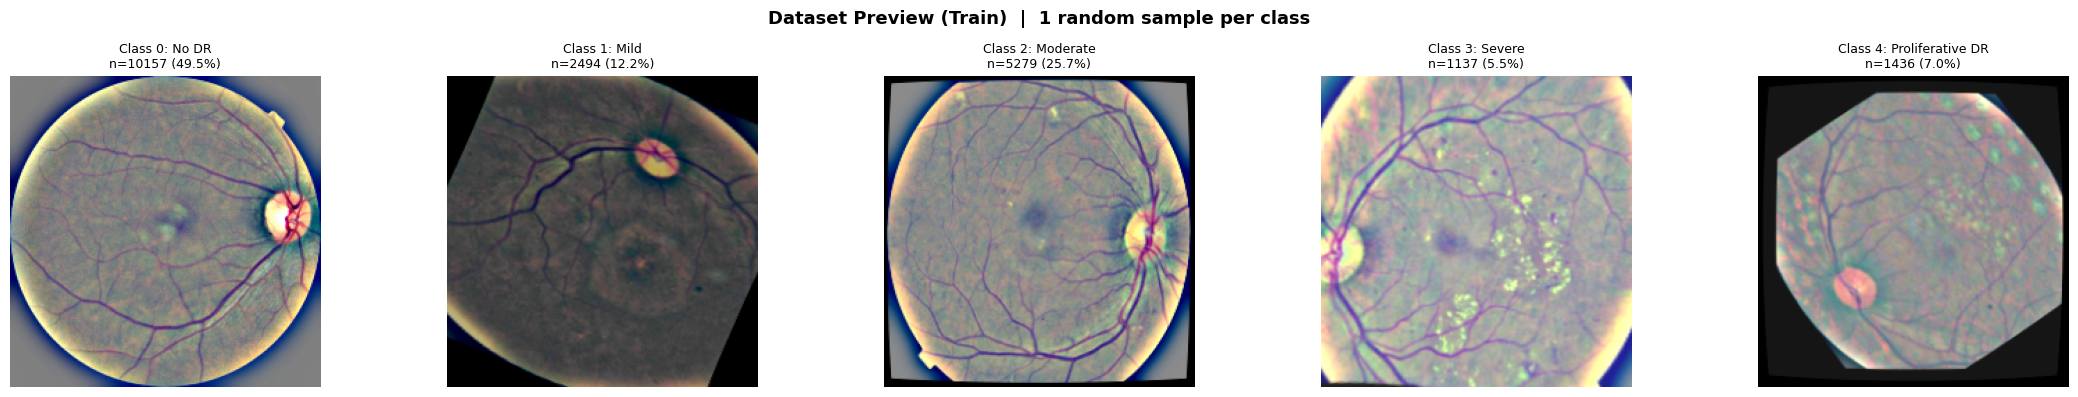


── Dataset Statistics ──────────────────────────────────
  Train: 20503 | Val: 366 | Test: 367
  Class distribution (train):
  [0] No DR               : 10157 ( 49.5%)  ██████████████
  [1] Mild                : 2494 ( 12.2%)  ███
  [2] Moderate            : 5279 ( 25.7%)  ███████
  [3] Severe              : 1137 (  5.5%)  █
  [4] Proliferative DR    : 1436 (  7.0%)  ██


In [6]:
def preview_dataset(df, image_dir, split_name="Train"):
    image_dir = Path(image_dir)
    img_col   = 'id_code' if 'id_code' in df.columns else df.columns[0]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(f"Dataset Preview ({split_name})  |  1 random sample per class",
                 fontsize=13, fontweight='bold')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = df[df['diagnosis'] == cls_idx]
        row    = subset.sample(1, random_state=42).iloc[0]
        fname  = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img    = Image.open(image_dir / fname).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\nn={len(subset)} ({100*len(subset)/len(df):.1f}%)",
            fontsize=9)
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n── Dataset Statistics ──────────────────────────────────")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n   = (train_df['diagnosis'] == i).sum()
        bar = '█' * int(30 * n / len(train_df))
        print(f"  [{i}] {name:<20s}: {n:4d} ({100*n/len(train_df):5.1f}%)  {bar}")

preview_dataset(train_df, f'{DATASET_DIR}/images')

In [7]:
class CoralHead(nn.Module):
    """K-1 shared-weight binary ordinal head (Cao et al., 2019)."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))
    def forward(self, x):
        return self.fc(x) + self.bias                      # (B, K-1)


class CornHead(nn.Module):
    """K-1 independent conditional binary classifiers (Shi, Cao & Raschka 2021)."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, num_classes - 1)
    def forward(self, x):
        return self.fc(x)                                  # (B, K-1) conditional logits


class RegHead(nn.Module):
    """Single scalar score in class-index space (0..K-1), trained with MSE."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1)
        nn.init.constant_(self.fc.bias, (num_classes - 1) / 2)   # start at the middle
    def forward(self, x):
        return self.fc(x)                                  # (B, 1)


def make_ordinal_head(in_features, num_classes=NUM_CLASSES):
    return {'coral': CoralHead, 'corn': CornHead, 'mse': RegHead}[ORDINAL_MODE](
        in_features, num_classes)

In [8]:
def coral_loss(logits, labels, num_classes=NUM_CLASSES):
    logits  = logits.float()
    targets = torch.zeros(labels.size(0), num_classes - 1, device=labels.device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return F.binary_cross_entropy_with_logits(logits, targets)


def corn_loss(logits, labels, num_classes=NUM_CLASSES):
    """Node k is trained only on samples with y > k-1 (all for k=0); target = (y > k)."""
    logits = logits.float()
    total, n = 0.0, 0.0
    for k in range(num_classes - 1):
        mask = labels > (k - 1)
        if mask.sum() < 1:
            continue
        tgt   = (labels[mask] > k).float()
        total = total + F.binary_cross_entropy_with_logits(
            logits[mask, k], tgt, reduction='sum')
        n += float(mask.sum())
    return total / max(n, 1.0)


def mse_loss(logits, labels):
    return F.mse_loss(logits.float().squeeze(1), labels.float())


def ord_loss(logits, labels):
    if ORDINAL_MODE == 'coral': return coral_loss(logits, labels)
    if ORDINAL_MODE == 'corn':  return corn_loss(logits, labels)
    return mse_loss(logits, labels)

In [9]:
def ord_cum_probs(logits):
    """P(Y > k) for k = 0..K-2  (CORAL / CORN only)."""
    p = torch.sigmoid(logits.float())
    return p if ORDINAL_MODE == 'coral' else torch.cumprod(p, dim=1)


def ord_predict(logits):
    if ORDINAL_MODE == 'mse':
        return logits.float().squeeze(1).round().clamp(0, NUM_CLASSES - 1).long()
    return (ord_cum_probs(logits) > 0.5).sum(dim=1).long()


def ord_logits_to_probs(logits):
    """Ordinal output -> normalised K-class probabilities (CORAL, CORN and MSE)."""
    if ORDINAL_MODE == 'mse':
        r  = logits.float()                                                  # (B,1)
        ks = torch.arange(NUM_CLASSES, device=logits.device).float().unsqueeze(0)
        return F.softmax(-((r - ks) ** 2) / MSE_TAU, dim=1)                  # (B,K)
    B = logits.size(0)
    cum        = ord_cum_probs(logits)                                       # (B, K-1)
    ones       = torch.ones (B, 1, device=logits.device)
    zeros      = torch.zeros(B, 1, device=logits.device)
    cum_padded = torch.cat([ones, cum, zeros], dim=1)                        # (B, K+1)
    probs      = (cum_padded[:, :-1] - cum_padded[:, 1:]).clamp(min=1e-8)
    return probs / probs.sum(dim=1, keepdim=True)


def ord_kd_targets(labels):
    """Binary targets (y > k) and 'active' mask of nodes that see each sample
    (CORAL / CORN only)."""
    ks      = torch.arange(NUM_CLASSES - 1, device=labels.device).unsqueeze(0)
    targets = (labels.unsqueeze(1) > ks).float()
    if ORDINAL_MODE == 'coral':
        active = torch.ones_like(targets)
    else:
        active = (labels.unsqueeze(1) > (ks - 1)).float()
    return targets, active

In [10]:
TEACHER_CE_DIM  = 2048   # ResNet-50 pooled feature
TEACHER_ORD_DIM = 1536   # EfficientNet-B3 pooled feature


class DualHeadStudent(nn.Module):
    """
    MobileNetV3-Small backbone
      + nominal (softmax) head          <- logit KD from ResNet-50-CE
      + ordinal (CORAL/CORN/MSE) head   <- logit KD from EfficientNet-B3-ordinal
      + 2 feature projectors            <- ONLY when BETA_FEAT > 0 (training only)
      + learnable scalar fusion gate.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        in_features = backbone.classifier[-1].in_features            # 1024
        backbone.classifier[-1] = nn.Identity()

        self.backbone     = backbone
        self.nominal_head = nn.Linear(in_features, num_classes)
        self.ordinal_head = make_ordinal_head(in_features, num_classes)
        if USE_FEAT:
            self.proj_ce  = nn.Linear(in_features, TEACHER_CE_DIM)
            self.proj_ord = nn.Linear(in_features, TEACHER_ORD_DIM)
        self.fusion_gate  = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        feat = self.backbone(x)
        return self.nominal_head(feat), self.ordinal_head(feat), feat

    def fused_probs(self, nominal_logits, ordinal_logits):
        p_nom = F.softmax(nominal_logits.float(), dim=1)
        p_ord = ord_logits_to_probs(ordinal_logits)
        w     = torch.sigmoid(self.fusion_gate)          # weight on NOMINAL branch
        p_final = w * p_nom + (1.0 - w) * p_ord
        return p_final / p_final.sum(dim=1, keepdim=True).clamp(min=1e-8)

In [11]:
def get_resnet50_ce_teacher():
    m    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def fwd_resnet_ce(model, imgs):                       # logits only
    return model(imgs)

def fwd_resnet_ce_feat(model, imgs):                  # (logits, pooled feature 2048)
    x = model.maxpool(model.relu(model.bn1(model.conv1(imgs))))
    x = model.layer4(model.layer3(model.layer2(model.layer1(x))))
    feat = model.avgpool(x).flatten(1)
    return model.fc(feat), feat


def get_efficientnet_b3_ord_teacher():
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features      = m.classifier[-1].in_features
    m.classifier[-1] = nn.Identity()
    m.ord_head       = make_ordinal_head(in_features, NUM_CLASSES)
    return m

def fwd_effnet_ord(model, imgs):                      # logits only
    feat = model.avgpool(model.features(imgs)).flatten(1)
    return model.ord_head(model.classifier(feat))

def fwd_effnet_ord_feat(model, imgs):                 # (logits, pooled feature 1536)
    feat = model.avgpool(model.features(imgs)).flatten(1)
    return model.ord_head(model.classifier(feat)), feat

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  METRICS  —  Acc, QWK, MAE, MSE, F1 (macro + weighted), AUC-ROC (OvR macro)
# ══════════════════════════════════════════════════════════════════════════════
METRIC_KEYS = [                 # (key, display name, display scale)
    ('acc',         'Accuracy (%)',            100.0),
    ('qwk',         'QWK',                       1.0),
    ('mae',         'MAE',                       1.0),
    ('mse',         'MSE',                       1.0),
    ('f1_macro',    'F1-score (macro)',          1.0),
    ('f1_weighted', 'F1-score (weighted)',       1.0),
    ('auc',         'AUC-ROC (OvR, macro)',      1.0),
]


def compute_all_metrics(y, p, probs=None):
    """y, p: integer class arrays. probs: (N, K) class probabilities (needed for AUC)."""
    y = np.asarray(y); p = np.asarray(p)
    mse = float(np.mean((y - p) ** 2))
    m = {'qwk':         float(cohen_kappa_score(y, p, weights='quadratic')),
         'acc':         float(np.mean(y == p)),
         'mae':         float(np.mean(np.abs(y - p))),
         'mse':         mse,
         'rmse':        float(np.sqrt(mse)),
         'f1_macro':    float(f1_score(y, p, average='macro',    zero_division=0)),
         'f1_weighted': float(f1_score(y, p, average='weighted', zero_division=0)),
         'auc':         float('nan')}
    if probs is not None:
        try:
            pr = np.asarray(probs, dtype=np.float64)
            pr = pr / pr.sum(axis=1, keepdims=True)            # sklearn wants rows == 1
            m['auc'] = float(roc_auc_score(y, pr, multi_class='ovr', average='macro',
                                           labels=list(range(NUM_CLASSES))))
        except ValueError:
            pass                                               # a class missing in y
    return m

In [13]:
# Teacher-side evaluators (unchanged tuple API used by train_teacher)
def _eval_loop(model, loader, pred_fn):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds_all.extend(pred_fn(model, imgs.to(device)).cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)


def _metrics(p, y):
    return (float(cohen_kappa_score(y, p, weights='quadratic')),
            float(np.mean(y == p)),
            float(np.mean(np.abs(y - p))),
            float(np.sqrt(np.mean((y - p) ** 2))),
            p.tolist(), y.tolist())


def evaluate_val_ce(model, loader):
    p, y = _eval_loop(model, loader, lambda m, x: m(x).argmax(dim=1))
    return _metrics(p, y)


def evaluate_val_ord(model, fwd_fn, loader):
    p, y = _eval_loop(model, loader, lambda m, x: ord_predict(fwd_fn(m, x)))
    return _metrics(p, y)

In [14]:
# Student-side evaluators (full metric set, including AUC from fused probabilities)
def dual_predict(model, nominal_logits, ordinal_logits):
    return model.fused_probs(nominal_logits, ordinal_logits).argmax(dim=1)


def _eval_loop_dual(model, loader):
    model.eval()
    preds_all, labels_all, probs_all = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            nom, ordl, _ = model(imgs.to(device))          # feature output ignored
            probs = model.fused_probs(nom, ordl)
            preds_all.extend(probs.argmax(dim=1).cpu().numpy())
            probs_all.append(probs.cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all), np.concatenate(probs_all, axis=0)


def evaluate_val_dual(model, loader):
    """-> (metrics dict, preds list, labels list)"""
    p, y, pr = _eval_loop_dual(model, loader)
    return compute_all_metrics(y, p, pr), p.tolist(), y.tolist()


def evaluate_on_test_dual(model, loader):
    p, y, pr = _eval_loop_dual(model, loader)
    out = compute_all_metrics(y, p, pr)
    out.update({'preds': p.tolist(), 'labels': y.tolist()})
    return out

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  PER-EPOCH PRINTING (also replays saved epochs when a session is resumed)
# ══════════════════════════════════════════════════════════════════════════════
def gate_label(w, tol=0.05):
    """w = sigmoid(fusion_gate) = weight on the NOMINAL branch."""
    if w is None:
        return "n/a"
    o = ORDINAL_MODE.upper()
    if w > 0.5 + tol:
        return f"leans NOMINAL ({w*100:.1f}% nom / {(1-w)*100:.1f}% {o})"
    if w < 0.5 - tol:
        return f"leans ORDINAL ({(1-w)*100:.1f}% {o} / {w*100:.1f}% nom)"
    return f"balanced ({w*100:.1f}% nom / {(1-w)*100:.1f}% {o})"


def print_epoch_line(epoch, loss, acc, qwk, mae, mse, f1, auc, gate_w, tag=""):
    """epoch is 1-based. None values (old checkpoints) are shown as n/a."""
    f = lambda v, fmt: format(v, fmt) if v is not None and not (isinstance(v, float) and math.isnan(v)) else "n/a"
    print(f"  {tag}Epoch {epoch:03d} | Loss: {f(loss, '.4f')} | "
          f"Acc: {f(None if acc is None else acc*100, '.2f')}% | QWK: {f(qwk, '.4f')} | "
          f"MAE: {f(mae, '.4f')} | MSE: {f(mse, '.4f')} | "
          f"F1: {f(f1, '.4f')} | AUC: {f(auc, '.4f')} | "
          f"NominalW: {f(gate_w, '.3f')} -> {gate_label(gate_w)}")
    sys.stdout.flush()


def replay_history(history, upto_epoch, last_n=REPLAY_LAST_N):
    """Re-print epochs already stored in a resumed checkpoint."""
    if upto_epoch <= 0:
        return
    start = 0 if last_n is None else max(0, upto_epoch - last_n)
    print(f"\n  ── Replaying epochs {start+1}–{upto_epoch} from checkpoint ──")
    for i in range(start, upto_epoch):
        print_epoch_line(
            i + 1,
            history['train_loss'][i], history['val_acc'][i], history['val_qwk'][i],
            history['val_mae'][i],    history['val_mse'][i], history['val_f1'][i],
            history['val_auc'][i],    history['fusion_weight'][i],
            tag="[resumed] ")
    print("  ── End of replay ──\n")

In [16]:
def train_teacher(model, fwd_fn, loss_fn, eval_fn, name, save_path, seed=33):
    """Only invoked if no pre-trained teacher checkpoint is found."""
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=T_LR, weight_decay=T_WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = load_resume_ckpt(
            resume_path, model, opt, sched, scaler)
        history.setdefault('val_mae',  [None] * len(history['val_qwk']))
        history.setdefault('val_rmse', [None] * len(history['val_qwk']))

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = loss_fn(fwd_fn(model, imgs), labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = loss_fn(fwd_fn(model, imgs), labels)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        qwk, acc, mae, rmse, vp, vl = eval_fn(model, val_loader)
        history['val_qwk'].append(qwk); history['val_acc'].append(acc)
        history['val_mae'].append(mae); history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | "
              f"MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk
            best_preds, best_labels = list(vp), list(vl)
            save_best_weights(save_path, epoch + 1, model, best_qwk)
        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(
        torch.load(save_path, map_location=device,
                   weights_only=False)['model_state_dict'])
    model.eval()
    print(f"\n  {name} best val QWK: {best_qwk:.4f}\n")
    return model

In [17]:
T_CE_CKPT  = f'{CKPT_DIR}/hybrid_teacher_resnet50_ce.pth'
T_ORD_CKPT = f'{CKPT_DIR}/hybrid_teacher_efficientnet_{ORDINAL_MODE}.pth'
_LEGACY_CORAL = f'{CKPT_DIR}/hyrid_teacher_efficientnet_coral.pth'   # old (typo) filename
if (ORDINAL_MODE == 'coral' and not os.path.exists(T_ORD_CKPT)
        and os.path.exists(_LEGACY_CORAL)):
    T_ORD_CKPT = _LEGACY_CORAL

t_ce  = get_resnet50_ce_teacher().to(device)
t_ord = get_efficientnet_b3_ord_teacher().to(device)


def _load(model, path):
    sd = torch.load(path, map_location=device, weights_only=False)['model_state_dict']
    sd = {k.replace('coral_head.', 'ord_head.').replace('corn_head.', 'ord_head.'): v
          for k, v in sd.items()}                              # old head key names
    model.load_state_dict(sd)


if os.path.exists(T_CE_CKPT):
    _load(t_ce, T_CE_CKPT); print("Loaded ResNet-50-CE teacher.")
else:
    set_seed(33)
    t_ce = train_teacher(model=t_ce, fwd_fn=fwd_resnet_ce,
                         loss_fn=lambda lg, lb: F.cross_entropy(lg, lb),
                         eval_fn=evaluate_val_ce, name="ResNet-50-CE",
                         save_path=T_CE_CKPT, seed=33)
    cleanup_memory()

if os.path.exists(T_ORD_CKPT):
    _load(t_ord, T_ORD_CKPT); print(f"Loaded EfficientNet-B3-{ORDINAL_MODE.upper()} teacher.")
else:
    set_seed(33)
    t_ord = train_teacher(model=t_ord, fwd_fn=fwd_effnet_ord, loss_fn=ord_loss,
                          eval_fn=lambda m, ld: evaluate_val_ord(m, fwd_effnet_ord, ld),
                          name=f"EfficientNet-B3-{ORDINAL_MODE.upper()}",
                          save_path=T_ORD_CKPT, seed=33)
    cleanup_memory()

t_ce.eval(); t_ord.eval()
for p in list(t_ce.parameters()) + list(t_ord.parameters()):
    p.requires_grad_(False)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 236MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 188MB/s]


Loaded ResNet-50-CE teacher.
Loaded EfficientNet-B3-CORAL teacher.


In [18]:
def dp_kd_loss(model, s_nom, s_ord, s_feat,
               t_ce_logits, t_ce_feat, t_ord_logits, t_ord_feat, labels,
               alpha=KD_ALPHA, temperature=KD_TEMPERATURE,
               fusion_weight=0.1, beta=None):
    """
    total = (1-alpha)*hard + alpha*kd_soft + fusion_weight*fused_nll + beta*feat_loss
      hard      : CE (nominal head) + CORAL/CORN/MSE (ordinal head)
      kd_soft   : response KD in each teacher's NATIVE space, confidence-weighted
      feat_loss : cosine feature KD to each teacher (only if beta > 0)
    """
    beta = BETA_FEAT if beta is None else beta
    T = temperature
    s_nom, s_ord = s_nom.float(), s_ord.float()
    t_ce_logits, t_ord_logits = t_ce_logits.float(), t_ord_logits.float()
    y_oh = F.one_hot(labels, NUM_CLASSES).float()

    # ---- Branch 1: nominal (categorical) ------------------------------------
    p_ce         = F.softmax(t_ce_logits / T, dim=1)
    ce_nominal   = -(y_oh * (p_ce + 1e-8).log()).sum(dim=1)
    conf_nominal = torch.exp(-ce_nominal).detach()
    kd_nominal   = F.kl_div(F.log_softmax(s_nom / T, dim=1), p_ce,
                            reduction='none').sum(dim=1) * (T ** 2)

    # ---- Branch 2: ordinal --------------------------------------------------
    if ORDINAL_MODE == 'mse':
        t_r = t_ord_logits.squeeze(1)
        s_r = s_ord.squeeze(1)
        ce_ordinal   = (t_r - labels.float()) ** 2               # teacher error vs label
        conf_ordinal = torch.exp(-ce_ordinal).detach()
        kd_ordinal   = ((s_r - t_r.detach()) ** 2) * MSE_KD_SCALE
    else:
        targets, active = ord_kd_targets(labels)
        bce_t = F.binary_cross_entropy_with_logits(t_ord_logits / T, targets,
                                                   reduction='none')
        ce_ordinal   = (bce_t * active).sum(1) / active.sum(1).clamp(min=1.0)
        conf_ordinal = torch.exp(-ce_ordinal).detach()
        t_soft = torch.sigmoid(t_ord_logits / T).detach()
        s_soft = torch.sigmoid(s_ord / T).clamp(1e-7, 1 - 1e-7)
        kd_ordinal = -(t_soft * s_soft.log()
                       + (1 - t_soft) * (1 - s_soft).log()).sum(dim=1) * (T ** 2)

    denom = conf_nominal + conf_ordinal + 1e-8
    w_nom, w_ord = conf_nominal / denom, conf_ordinal / denom
    kd_soft = (w_nom * kd_nominal + w_ord * kd_ordinal).mean()

    # ---- Feature distillation (cosine), per-teacher, same confidence weights --
    feat_loss = torch.zeros((), device=labels.device)
    if beta > 0 and s_feat is not None:
        s_feat  = s_feat.float()
        cos_ce  = F.cosine_similarity(model.proj_ce (s_feat), t_ce_feat.float().detach(),  dim=1)
        cos_ord = F.cosine_similarity(model.proj_ord(s_feat), t_ord_feat.float().detach(), dim=1)
        feat_loss = (w_nom * (1 - cos_ce) + w_ord * (1 - cos_ord)).mean()

    # ---- Hard labels + fusion gate --------------------------------------------
    hard = 0.5 * F.cross_entropy(s_nom, labels) + 0.5 * ord_loss(s_ord, labels)
    p_final   = model.fused_probs(s_nom, s_ord)
    fused_nll = F.nll_loss(torch.log(p_final.clamp(min=1e-8)), labels)

    return ((1.0 - alpha) * hard + alpha * kd_soft
            + fusion_weight * fused_nll + beta * feat_loss)

In [19]:
def _student_step_loss(student, t_ce_ref, t_ord_ref, imgs, labels):
    s_nom, s_ord, s_feat = student(imgs)
    with torch.no_grad():
        if USE_FEAT:
            t_ce_logits,  t_ce_feat  = fwd_resnet_ce_feat(t_ce_ref,  imgs)
            t_ord_logits, t_ord_feat = fwd_effnet_ord_feat(t_ord_ref, imgs)
        else:                                   # logit-only: skip feature path
            t_ce_logits,  t_ce_feat  = fwd_resnet_ce(t_ce_ref,  imgs), None
            t_ord_logits, t_ord_feat = fwd_effnet_ord(t_ord_ref, imgs), None
    return dp_kd_loss(student, s_nom, s_ord, s_feat,
                      t_ce_logits, t_ce_feat, t_ord_logits, t_ord_feat, labels)


def _ckpt_paths(seed):
    fs  = 'feat' if USE_FEAT else 'logit'
    tag = f'dpkd_{fs}_{ORDINAL_MODE}_seed{seed}'
    best, resume = f'{CKPT_DIR}/{tag}_best.pth', f'{CKPT_DIR}/{tag}_resume.pth'

    # legacy names from earlier logit-only notebooks (finished runs are still picked up)
    if not USE_FEAT:
        legacy = {'coral': f'dpkd_seed{seed}', 'corn': f'dpkd_corn_seed{seed}'}.get(ORDINAL_MODE)
        if legacy and not os.path.exists(resume) \
                and os.path.exists(f'{CKPT_DIR}/{legacy}_resume.pth'):
            best, resume = f'{CKPT_DIR}/{legacy}_best.pth', f'{CKPT_DIR}/{legacy}_resume.pth'
    return best, resume

In [20]:
HIST_KEYS = ['val_mae', 'val_rmse', 'val_mse', 'val_f1', 'val_auc', 'fusion_weight']


def train_dual_student(seed, t_ce_model, t_ord_model):
    best_path, resume_path = _ckpt_paths(seed)

    set_seed(seed)
    student   = DualHeadStudent(NUM_CLASSES).to(device)
    t_ce_ref  = t_ce_model.to(device).eval()
    t_ord_ref = t_ord_model.to(device).eval()
    for p in list(t_ce_ref.parameters()) + list(t_ord_ref.parameters()):
        p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=S_LR, weight_decay=S_WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                   'val_mae': [], 'val_rmse': [], 'val_mse': [],
                   'val_f1': [], 'val_auc': [], 'fusion_weight': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)
        for k in HIST_KEYS:          # older checkpoints lack the new metrics -> None
            history.setdefault(k, [None] * len(history['val_qwk']))
        replay_history(history, start_epoch)                 # print saved epochs

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            opt.zero_grad()
            if USE_AMP:
                with torch.amp.autocast('cuda'):
                    loss = _student_step_loss(student, t_ce_ref, t_ord_ref, imgs, labels)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else:
                loss = _student_step_loss(student, t_ce_ref, t_ord_ref, imgs, labels)
                loss.backward(); opt.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        mt, vp, vl = evaluate_val_dual(student, val_loader)
        gate_w = float(torch.sigmoid(student.fusion_gate).item())
        history['val_qwk'].append(mt['qwk']);   history['val_acc'].append(mt['acc'])
        history['val_mae'].append(mt['mae']);   history['val_rmse'].append(mt['rmse'])
        history['val_mse'].append(mt['mse']);   history['val_f1'].append(mt['f1_macro'])
        history['val_auc'].append(mt['auc']);   history['fusion_weight'].append(gate_w)

        print_epoch_line(epoch + 1, avg_loss, mt['acc'], mt['qwk'], mt['mae'],
                         mt['mse'], mt['f1_macro'], mt['auc'], gate_w)

        if mt['qwk'] > best_qwk:                               # model selection: val QWK
            best_qwk = mt['qwk']
            best_preds, best_labels = list(vp), list(vl)
            save_best_weights(best_path, epoch + 1, student, best_qwk)
        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=False)['model_state_dict'])
    student.eval()
    bw = float(torch.sigmoid(student.fusion_gate).item())
    print(f"  Seed {seed} BEST model (val QWK={best_qwk:.4f}): {gate_label(bw)}")

    # full metric set of the BEST checkpoint (works even for resumed / old runs)
    val_final, _, _ = evaluate_val_dual(student, val_loader)
    print("  Val (best): " + " | ".join(
        f"{name.split(' (')[0]}={val_final[k]*sc:.4f}" for k, name, sc in METRIC_KEYS))
    return {'qwk': best_qwk, 'history': history, 'val_final': val_final,
            'preds': best_preds, 'labels': best_labels,
            'seed': seed, 'model': student}

In [21]:
def metric_summary_lines(dicts, header):
    """mean ± std [min – max] over seeds for every metric in METRIC_KEYS."""
    out = [f"  {header}"]
    for k, name, sc in METRIC_KEYS:
        v = np.array([d[k] for d in dicts], dtype=float) * sc
        out.append(f"    {name:<24s}: {np.nanmean(v):.4f} ± {np.nanstd(v):.4f}"
                   f"  [{np.nanmin(v):.4f} – {np.nanmax(v):.4f}]")
    return out


def print_metric_table(results_list, test_results_list):
    """Per-seed table for validation (best ckpt) and test."""
    cols = [name.split(' (')[0] for _, name, _ in METRIC_KEYS]
    for title, rows in [('VALIDATION (best-QWK epoch)', [(r['seed'], r['val_final']) for r in results_list]),
                        ('TEST', [(t['seed'], t) for t in test_results_list])]:
        print(f"\n  {title}")
        print("  " + f"{'Seed':>5s}  " + "  ".join(f"{c:>12s}" for c in cols))
        for seed, d in rows:
            print("  " + f"{seed:>5d}  " + "  ".join(
                f"{d[k]*sc:>12.4f}" for k, _, sc in METRIC_KEYS))

In [22]:
def analyse_results(results_list, scenario_title,
                    loss_label="Loss", test_results_list=None):
    seeds       = [r['seed'] for r in results_list]
    all_losses  = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks    = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs    = np.array([r['history']['val_acc']    for r in results_list])
    all_maes    = np.array([r['history']['val_mae']    for r in results_list], dtype=float)
    epochs      = np.arange(1, all_losses.shape[1] + 1)
    best_res    = max(results_list, key=lambda x: x['qwk'])
    colors      = plt.cm.tab10.colors

    cms         = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
                   for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs   = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100
                   for r in results_list]
    seed_maes   = [np.mean(np.abs(np.array(r['labels']) - np.array(r['preds'])))
                   for r in results_list]
    mean_acc    = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk    = np.mean([r['qwk'] for r in results_list])
    std_qwk     = np.std([r['qwk']  for r in results_list])
    mean_mae    = np.mean(seed_maes);  std_mae  = np.std(seed_maes)
    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = sorted(
        [(cm_avg[i,j], i, j) for i in range(NUM_CLASSES)
         for j in range(NUM_CLASSES) if i != j and cm_avg[i,j] > 0],
        reverse=True)

    report   = classification_report(best_res['labels'], best_res['preds'],
                                     target_names=CLASS_NAMES, output_dict=True)
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    safe     = re.sub(r'[^A-Za-z0-9_.+-]+', '_', scenario_title)

    def _ann(ax, cm, fmt='count'):
        thresh = cm.max() / 2
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                v = cm[i, j]
                t = f"{v:.3f}" if fmt == 'norm' else f"{v:.0f}"
                ax.text(j, i, t, ha='center', va='center', fontsize=7.5,
                        color='white' if v > thresh else 'black')

    # ── Dashboard 4×4 ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(24, 20))
    fig.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                 fontsize=16, fontweight='bold', y=0.99)
    gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.42, wspace=0.30)

    for col, (data, color, yl, title, mu, std) in enumerate([
        (seed_accs, '#aec6e8', 'Accuracy (%)', f'Val Accuracy ({len(seeds)} Seeds)',
         mean_acc, std_acc),
        ([r['qwk'] for r in results_list], '#b8d4a8', 'QWK',
         f'Val QWK ({len(seeds)} Seeds)', mean_qwk, std_qwk),
        (seed_maes, '#f4c2c2', 'MAE', f'Val MAE ({len(seeds)} Seeds)',
         mean_mae, std_mae),
    ]):
        ax = fig.add_subplot(gs[0, col])
        bp = ax.boxplot([data], patch_artist=True, widths=0.4,
                        medianprops=dict(color='red', lw=2))
        bp['boxes'][0].set_facecolor(color)
        ax.scatter([1]*len(data), data, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_ylabel(yl); ax.grid(True, axis='y', ls='--', alpha=0.5)
        fmt = f"μ={mu:.2f}%\nσ={std:.2f}%" if col == 0 else f"μ={mu:.4f}\nσ={std:.4f}"
        ax.text(1, mu, fmt, ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig.add_subplot(gs[0, 3])
    ml = all_losses.mean(0); sl = all_losses.std(0)
    ax.plot(epochs, ml, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, ml-sl, ml+sl, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ma = all_accs.mean(0)*100; sa = all_accs.std(0)*100
    mq = all_qwks.mean(0);     sq = all_qwks.std(0)
    valid = ~np.isnan(all_maes).all(axis=0)
    mm = np.nanmean(all_maes, axis=0); sm = np.nanstd(all_maes, axis=0)

    for col, (y, sy, ep, color, yl, title) in enumerate([
        (ma, sa, epochs,        '#1f77b4', 'Accuracy (%)', 'Val Accuracy Curves'),
        (mq, sq, epochs,        '#2ca02c', 'QWK',          'Val QWK Curves'),
        (mm[valid], sm[valid], epochs[valid], '#d62728', 'MAE', 'Val MAE Curves'),
    ]):
        ax = fig.add_subplot(gs[1, col])
        ax.plot(ep, y, color=color, lw=2.2, label='Mean')
        ax.fill_between(ep, y-sy, y+sy, alpha=0.25, color=color, label='±1 std')
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
        ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[1, 3])
    ax.plot(epochs, all_qwks.mean(0)/(all_losses.mean(0)+1e-8),
            color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[2, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a*100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs, ma, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Acc Curves", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[2, 1])
    for i, r in enumerate(results_list):
        mr = [m for m in r['history']['val_mae'] if m is not None]
        ax.plot(epochs[:len(mr)], mr, color=colors[i], lw=1.5,
                alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs[valid], mm[valid], 'k--', lw=2.2, label='Average')
    ax.set_title("Individual MAE Curves", fontweight='bold', fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    for col, (cm, cmap, title, fmt) in enumerate([
        (cm_avg,      'Blues', 'Avg CM (Raw Counts)',  'count'),
        (cm_avg_norm, 'Blues', 'Avg CM (Normalised)', 'norm'),
    ]):
        ax = fig.add_subplot(gs[2, 2+col])
        im = ax.imshow(cm, cmap=cmap, interpolation='nearest',
                       **({'vmin': 0, 'vmax': 1} if fmt == 'norm' else {}))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
        ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(title, fontweight='bold', fontsize=11)
        _ann(ax, cm, fmt)

    ax = fig.add_subplot(gs[3, 0])
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc*100,
                  color='#aec6e8', edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val*100:.1f}%", ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy (Avg CM)", fontweight='bold', fontsize=11)
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig.add_subplot(gs[3, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("CM Std Dev", fontweight='bold', fontsize=11)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center',
                    va='center', fontsize=7.5, color='black')

    ax = fig.add_subplot(gs[3, 2])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Best CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontweight='bold', fontsize=11)
    _ann(ax, cm_best)

    ax = fig.add_subplot(gs[3, 3])
    f1s = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1b = ax.bar(range(NUM_CLASSES), [f*100 for f in f1s],
                 color='#b8d4a8', edgecolor='grey', lw=0.8)
    for bar, val in zip(f1b, f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val*100:.1f}%", ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 (Best Seed)", fontweight='bold', fontsize=11)
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    plt.savefig(f'{CKPT_DIR}/{safe}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Detailed CM figure + summary text ─────────────────────────────────────
    fig2 = plt.figure(figsize=(20, 23))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.85])
    for row, col, cm, cmap, title, fmt in [
        (0, 0, cm_avg,      'Blues',   'Average CM (Raw Counts)',   'count'),
        (0, 1, cm_avg_norm, 'Blues',   'Average CM (Normalised)',   'norm'),
        (1, 0, cm_std,      'Oranges', 'CM Standard Deviation',     'std'),
        (1, 1, cm_best,     'Greens',  f'Best CM (Seed {best_res["seed"]})', 'count'),
    ]:
        ax = fig2.add_subplot(gs2[row, col])
        kw = {'vmin': 0, 'vmax': 1} if fmt == 'norm' else {}
        im = ax.imshow(cm, cmap=cmap, interpolation='nearest', **kw)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
        ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(title, fontweight='bold', fontsize=12)
        if fmt == 'std':
            for i in range(NUM_CLASSES):
                for j in range(NUM_CLASSES):
                    ax.text(j, i, f"{cm[i,j]:.2f}", ha='center',
                            va='center', fontsize=8.5, color='black')
        else:
            _ann(ax, cm, fmt)

    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')
    best_mae = np.mean(np.abs(np.array(best_res['labels']) - np.array(best_res['preds'])))
    lines = ["=" * 80,
             f"  PERFORMANCE SUMMARY — {scenario_title}",
             "=" * 80,
             f"  Seeds trained              : {seeds}",
             f"  Best seed                  : Seed {best_res['seed']}"
             f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%, MAE={best_mae:.4f})",
             f"  Final train loss (mean)    : "
             f"{all_losses[:,-1].mean():.4f} ± {all_losses[:,-1].std():.4f}",
             f"  Peak QWK epoch  (mean)     : "
             f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}",
             ""]
    lines += metric_summary_lines([r['val_final'] for r in results_list],
                                  "Validation metrics (best-QWK checkpoint), mean ± std [min – max]:")
    lines.append("")
    if test_results_list:
        lines += metric_summary_lines(test_results_list,
                                      "Test metrics, mean ± std [min – max]:")
        lines.append("")
    lines += ["  Per-class Performance (best seed, validation):",
              f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
              f"{'F1-Score':>9s}  {'Support':>7s}",
              "  " + "-" * 60]
    for cls in CLASS_NAMES:
        d = report[cls]
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}")
    lines += ["  " + "-" * 60,
              f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
              f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}",
              f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
              f"{report['macro avg']['recall']:>9.3f}  "
              f"{report['macro avg']['f1-score']:>9.3f}",
              f"  {'Weighted Avg F1':<20s}  "
              f"{report['weighted avg']['precision']:>9.3f}  "
              f"{report['weighted avg']['recall']:>9.3f}  "
              f"{report['weighted avg']['f1-score']:>9.3f}",
              "",
              "  Top-5 Most Common Misclassifications (averaged across seeds):"]
    for rank, (cnt, tc, pc) in enumerate(misclass[:5], 1):
        pct = cnt / cm_avg.sum(axis=1)[tc] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[tc]:<20s} → "
                     f"Predicted={CLASS_NAMES[pc]:<20s}"
                     f"  (avg={cnt:.1f}, {pct:.1f}% of true class)")
    cls_s = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines += ["", "  Class Accuracy Range (averaged CM):",
              f"    Best : {cls_s[0][1]}  ({cls_s[0][0]*100:.1f}%)",
              f"    Worst: {cls_s[-1][1]}  ({cls_s[-1][0]*100:.1f}%)",
              f"    Gap  : {(cls_s[0][0]-cls_s[-1][0])*100:.1f}pp",
              "=" * 80]
    ax_txt.text(0.01, 0.99, '\n'.join(lines), transform=ax_txt.transAxes,
                fontsize=8.0, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa',
                          alpha=0.9, edgecolor='#dee2e6'))
    plt.savefig(f'{CKPT_DIR}/{safe}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\n'.join(lines))

In [23]:
results_dpkd, trained_dpkd = [], []
for seed in SEEDS:
    print(f"\n  DP-KD {KD_KIND} | ResNet-50-CE + EfficientNet-B3-{ORDINAL_MODE.upper()} "
          f"-> MobileNetV3-Small | Seed {seed}\n")
    res = train_dual_student(seed, t_ce, t_ord)
    results_dpkd.append(res); trained_dpkd.append(res['model'])
    cleanup_memory()


  DP-KD logit | ResNet-50-CE + EfficientNet-B3-CORAL -> MobileNetV3-Small | Seed 33

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 191MB/s]

  ↺ Resumed from epoch 100  (best QWK so far: 0.9009)

  ── Replaying epochs 1–100 from checkpoint ──
  [resumed] Epoch 001 | Loss: 72.2415 | Acc: 69.95% | QWK: 0.8187 | MAE: 0.3798 | MSE: 0.5710 | F1: 0.4955 | AUC: 0.9233 | NominalW: 0.632 -> leans NOMINAL (63.2% nom / 36.8% CORAL)
  [resumed] Epoch 002 | Loss: 67.6871 | Acc: 71.86% | QWK: 0.8836 | MAE: 0.3142 | MSE: 0.3907 | F1: 0.5255 | AUC: 0.9234 | NominalW: 0.729 -> leans NOMINAL (72.9% nom / 27.1% CORAL)
  [resumed] Epoch 003 | Loss: 65.5601 | Acc: 73.77% | QWK: 0.8390 | MAE: 0.3197 | MSE: 0.4563 | F1: 0.5790 | AUC: 0.9177 | NominalW: 0.794 -> leans NOMINAL (79.4% nom / 20.6% CORAL)
  [resumed] Epoch 004 | Loss: 64.4217 | Acc: 77.87% | QWK: 0.8678 | MAE: 0.2814 | MSE: 0.4071 | F1: 0.6228 | AUC: 0.9323 | NominalW: 0.839 -> leans NOMINAL (83.9% nom / 16.1% CORAL)
  [resumed] Epoch 005 | Loss: 63.5372 | Acc: 78.14% | QWK: 0.8756 | MAE: 0.2732 | MSE: 0.3934 | F1: 0.6286 | AUC: 0.9283 | NominalW: 0.870 -> leans NOMINAL (87.0% nom / 1

  [resumed] Epoch 018 | Loss: 60.0510 | Acc: 79.23% | QWK: 0.8761 | MAE: 0.2650 | MSE: 0.3907 | F1: 0.6204 | AUC: 0.9306 | NominalW: 0.891 -> leans NOMINAL (89.1% nom / 10.9% CORAL)
  [resumed] Epoch 019 | Loss: 59.2065 | Acc: 77.87% | QWK: 0.8802 | MAE: 0.2705 | MSE: 0.3852 | F1: 0.6239 | AUC: 0.9273 | NominalW: 0.885 -> leans NOMINAL (88.5% nom / 11.5% CORAL)
  [resumed] Epoch 020 | Loss: 59.5187 | Acc: 76.78% | QWK: 0.8784 | MAE: 0.2760 | MSE: 0.3743 | F1: 0.6270 | AUC: 0.9307 | NominalW: 0.880 -> leans NOMINAL (88.0% nom / 12.0% CORAL)
  [resumed] Epoch 021 | Loss: 59.6108 | Acc: 79.23% | QWK: 0.8860 | MAE: 0.2541 | MSE: 0.3634 | F1: 0.6323 | AUC: 0.9195 | NominalW: 0.871 -> leans NOMINAL (87.1% nom / 12.9% CORAL)
  [resumed] Epoch 022 | Loss: 59.4101 | Acc: 75.68% | QWK: 0.8648 | MAE: 0.3005 | MSE: 0.4208 | F1: 0.5748 | AUC: 0.9256 | NominalW: 0.866 -> leans NOMINAL (86.6% nom / 13.4% CORAL)
  [resumed] Epoch 023 | Loss: 59.3201 | Acc: 79.23% | QWK: 0.8926 | MAE: 0.2459 | MSE: 0.3

In [24]:
test_results_dpkd = []
for seed, student_model, res in zip(SEEDS, trained_dpkd, results_dpkd):
    tr = evaluate_on_test_dual(student_model, test_loader)
    tr['seed'] = seed; tr['history'] = res['history']
    test_results_dpkd.append(tr)
    print(f"  Seed {seed} Test | " + " | ".join(
        f"{name.split(' (')[0]}={tr[k]*sc:.4f}" for k, name, sc in METRIC_KEYS))

print_metric_table(results_dpkd, test_results_dpkd)

  Seed 33 Test | Accuracy=83.9237 | QWK=0.9026 | MAE=0.2044 | MSE=0.3025 | F1-score=0.6900 | F1-score=0.8354 | AUC-ROC=0.9329
  Seed 81 Test | Accuracy=80.1090 | QWK=0.8698 | MAE=0.2589 | MSE=0.4060 | F1-score=0.6385 | F1-score=0.8017 | AUC-ROC=0.9338
  Seed 5 Test | Accuracy=77.3842 | QWK=0.8748 | MAE=0.2779 | MSE=0.3978 | F1-score=0.6176 | F1-score=0.7775 | AUC-ROC=0.9290

  VALIDATION (best-QWK epoch)
   Seed      Accuracy           QWK           MAE           MSE      F1-score      F1-score       AUC-ROC
     33       81.6940        0.9009        0.2240        0.3060        0.6595        0.8159        0.9305
     81       80.3279        0.9082        0.2268        0.2869        0.6409        0.8011        0.9309
      5       75.4098        0.8912        0.2787        0.3443        0.5918        0.7611        0.9315

  TEST
   Seed      Accuracy           QWK           MAE           MSE      F1-score      F1-score       AUC-ROC
     33       83.9237        0.9026        0.2044     

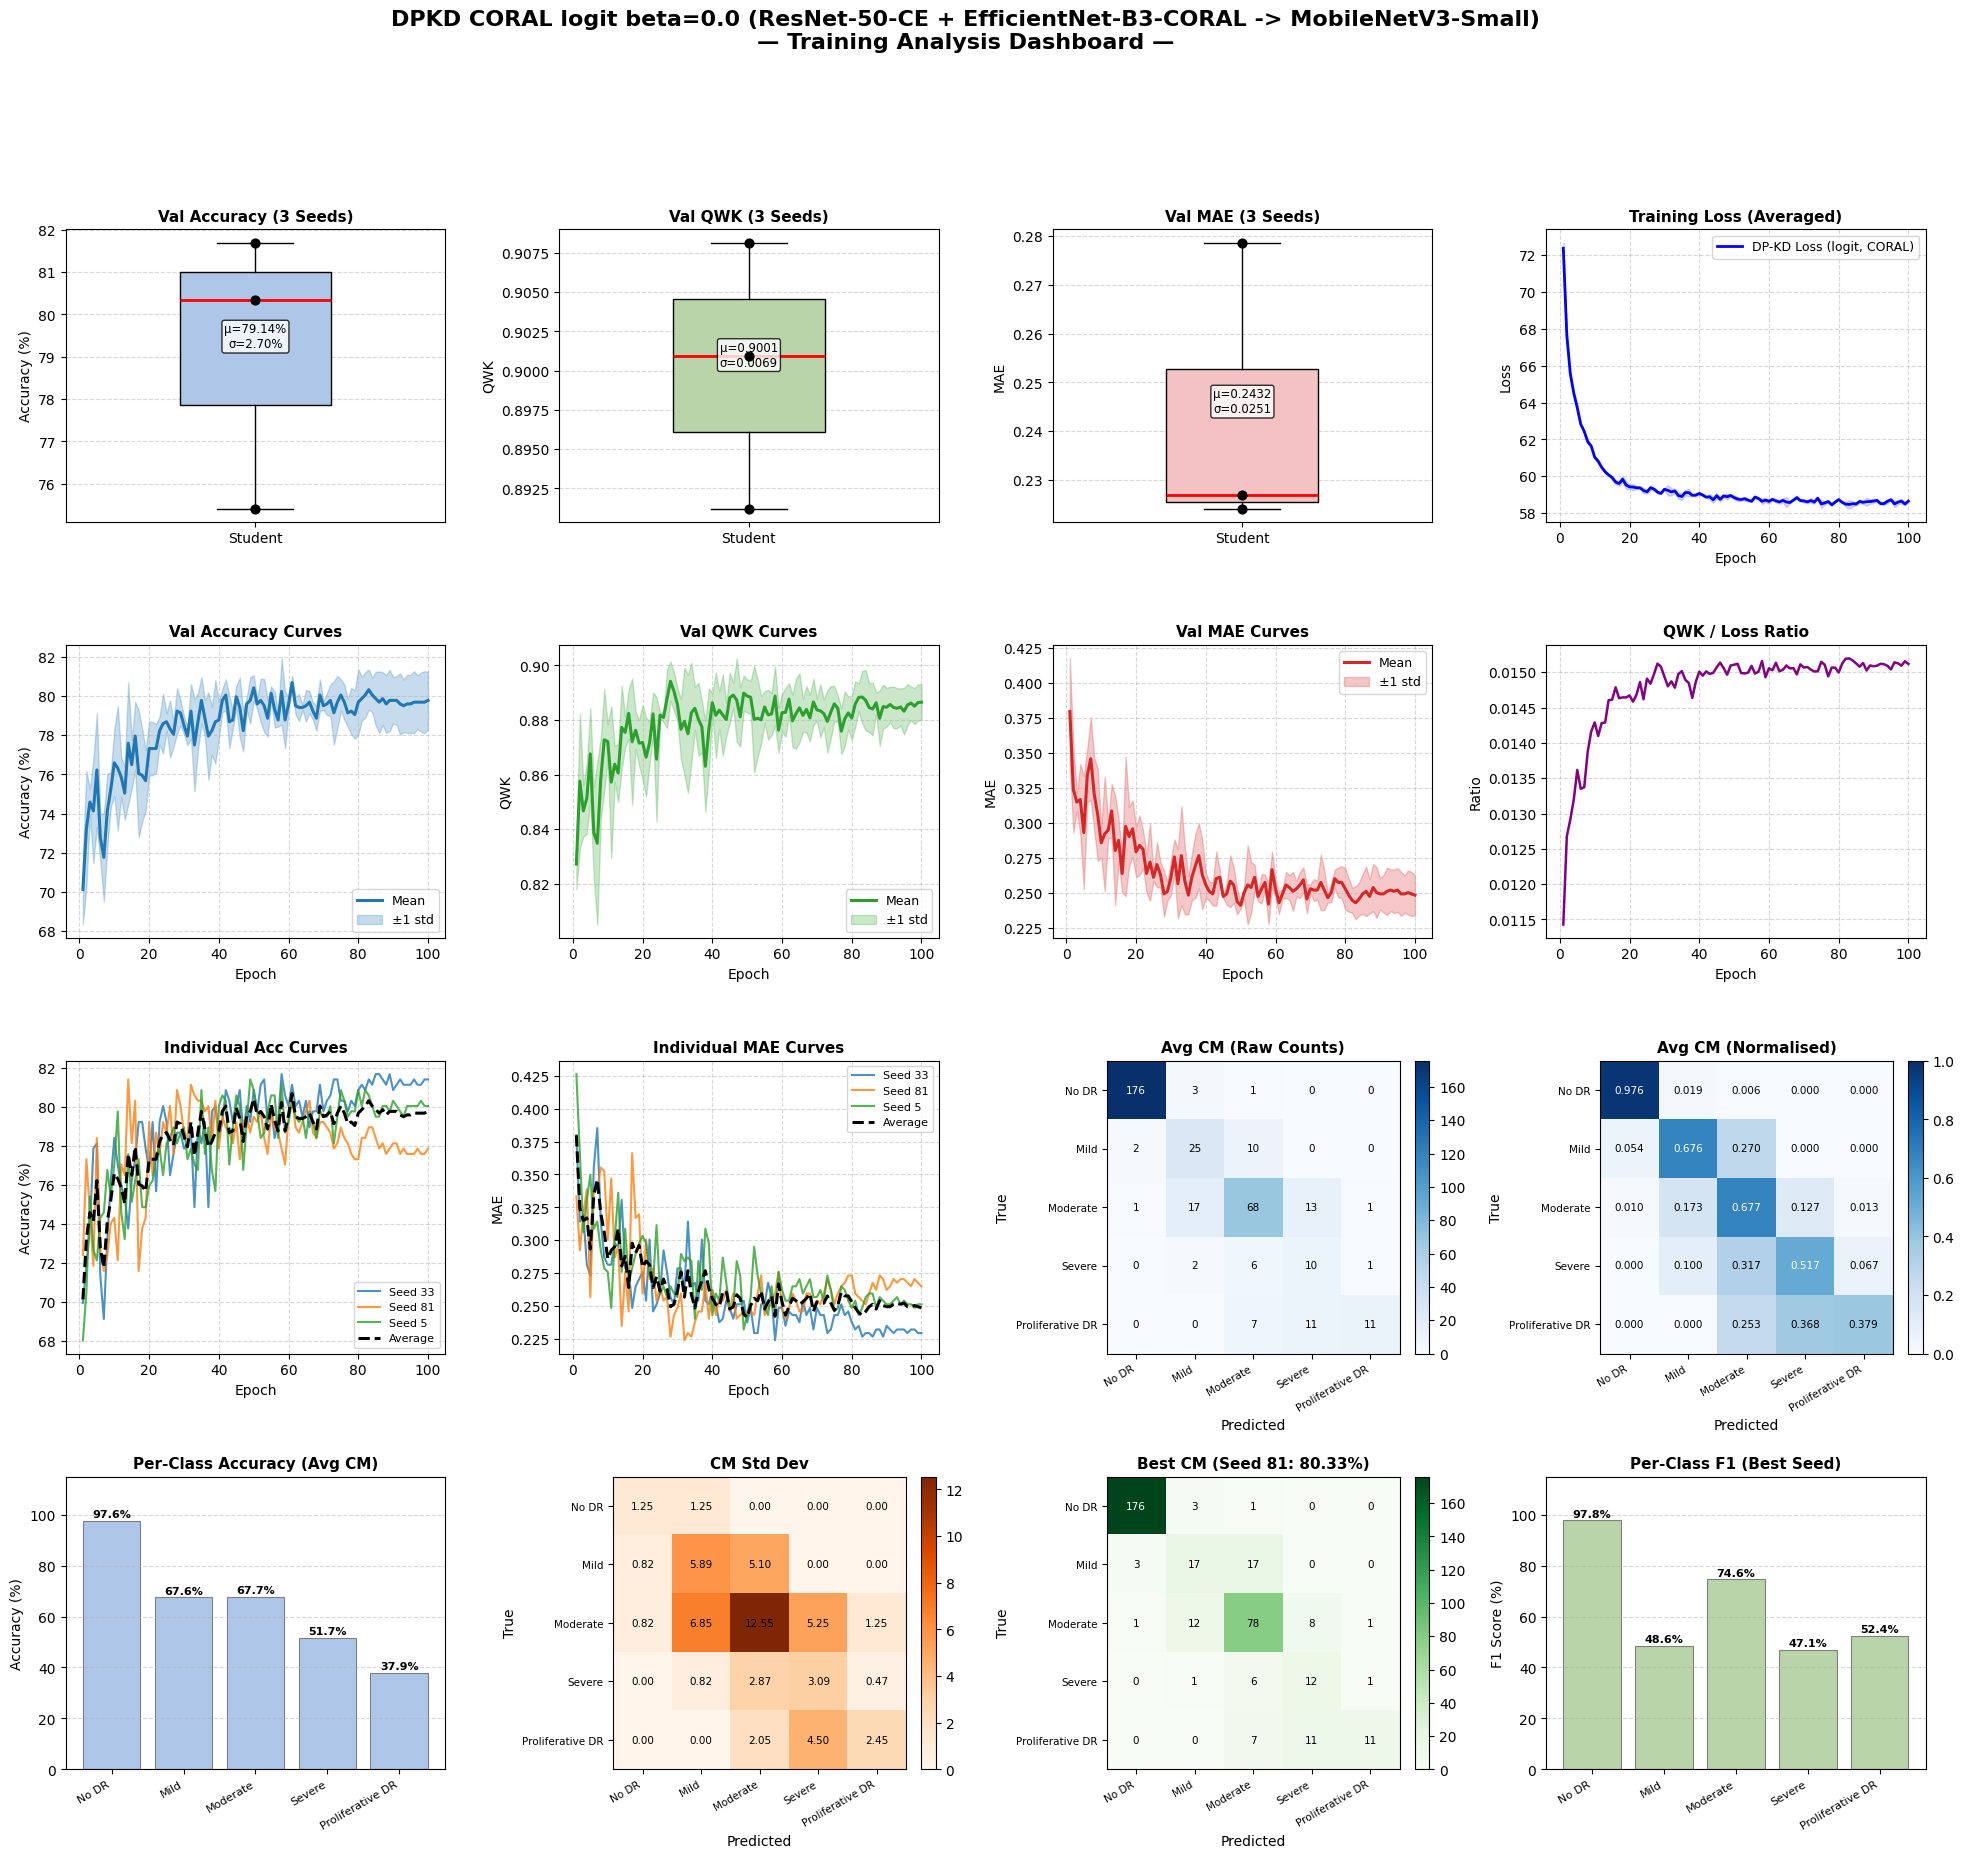

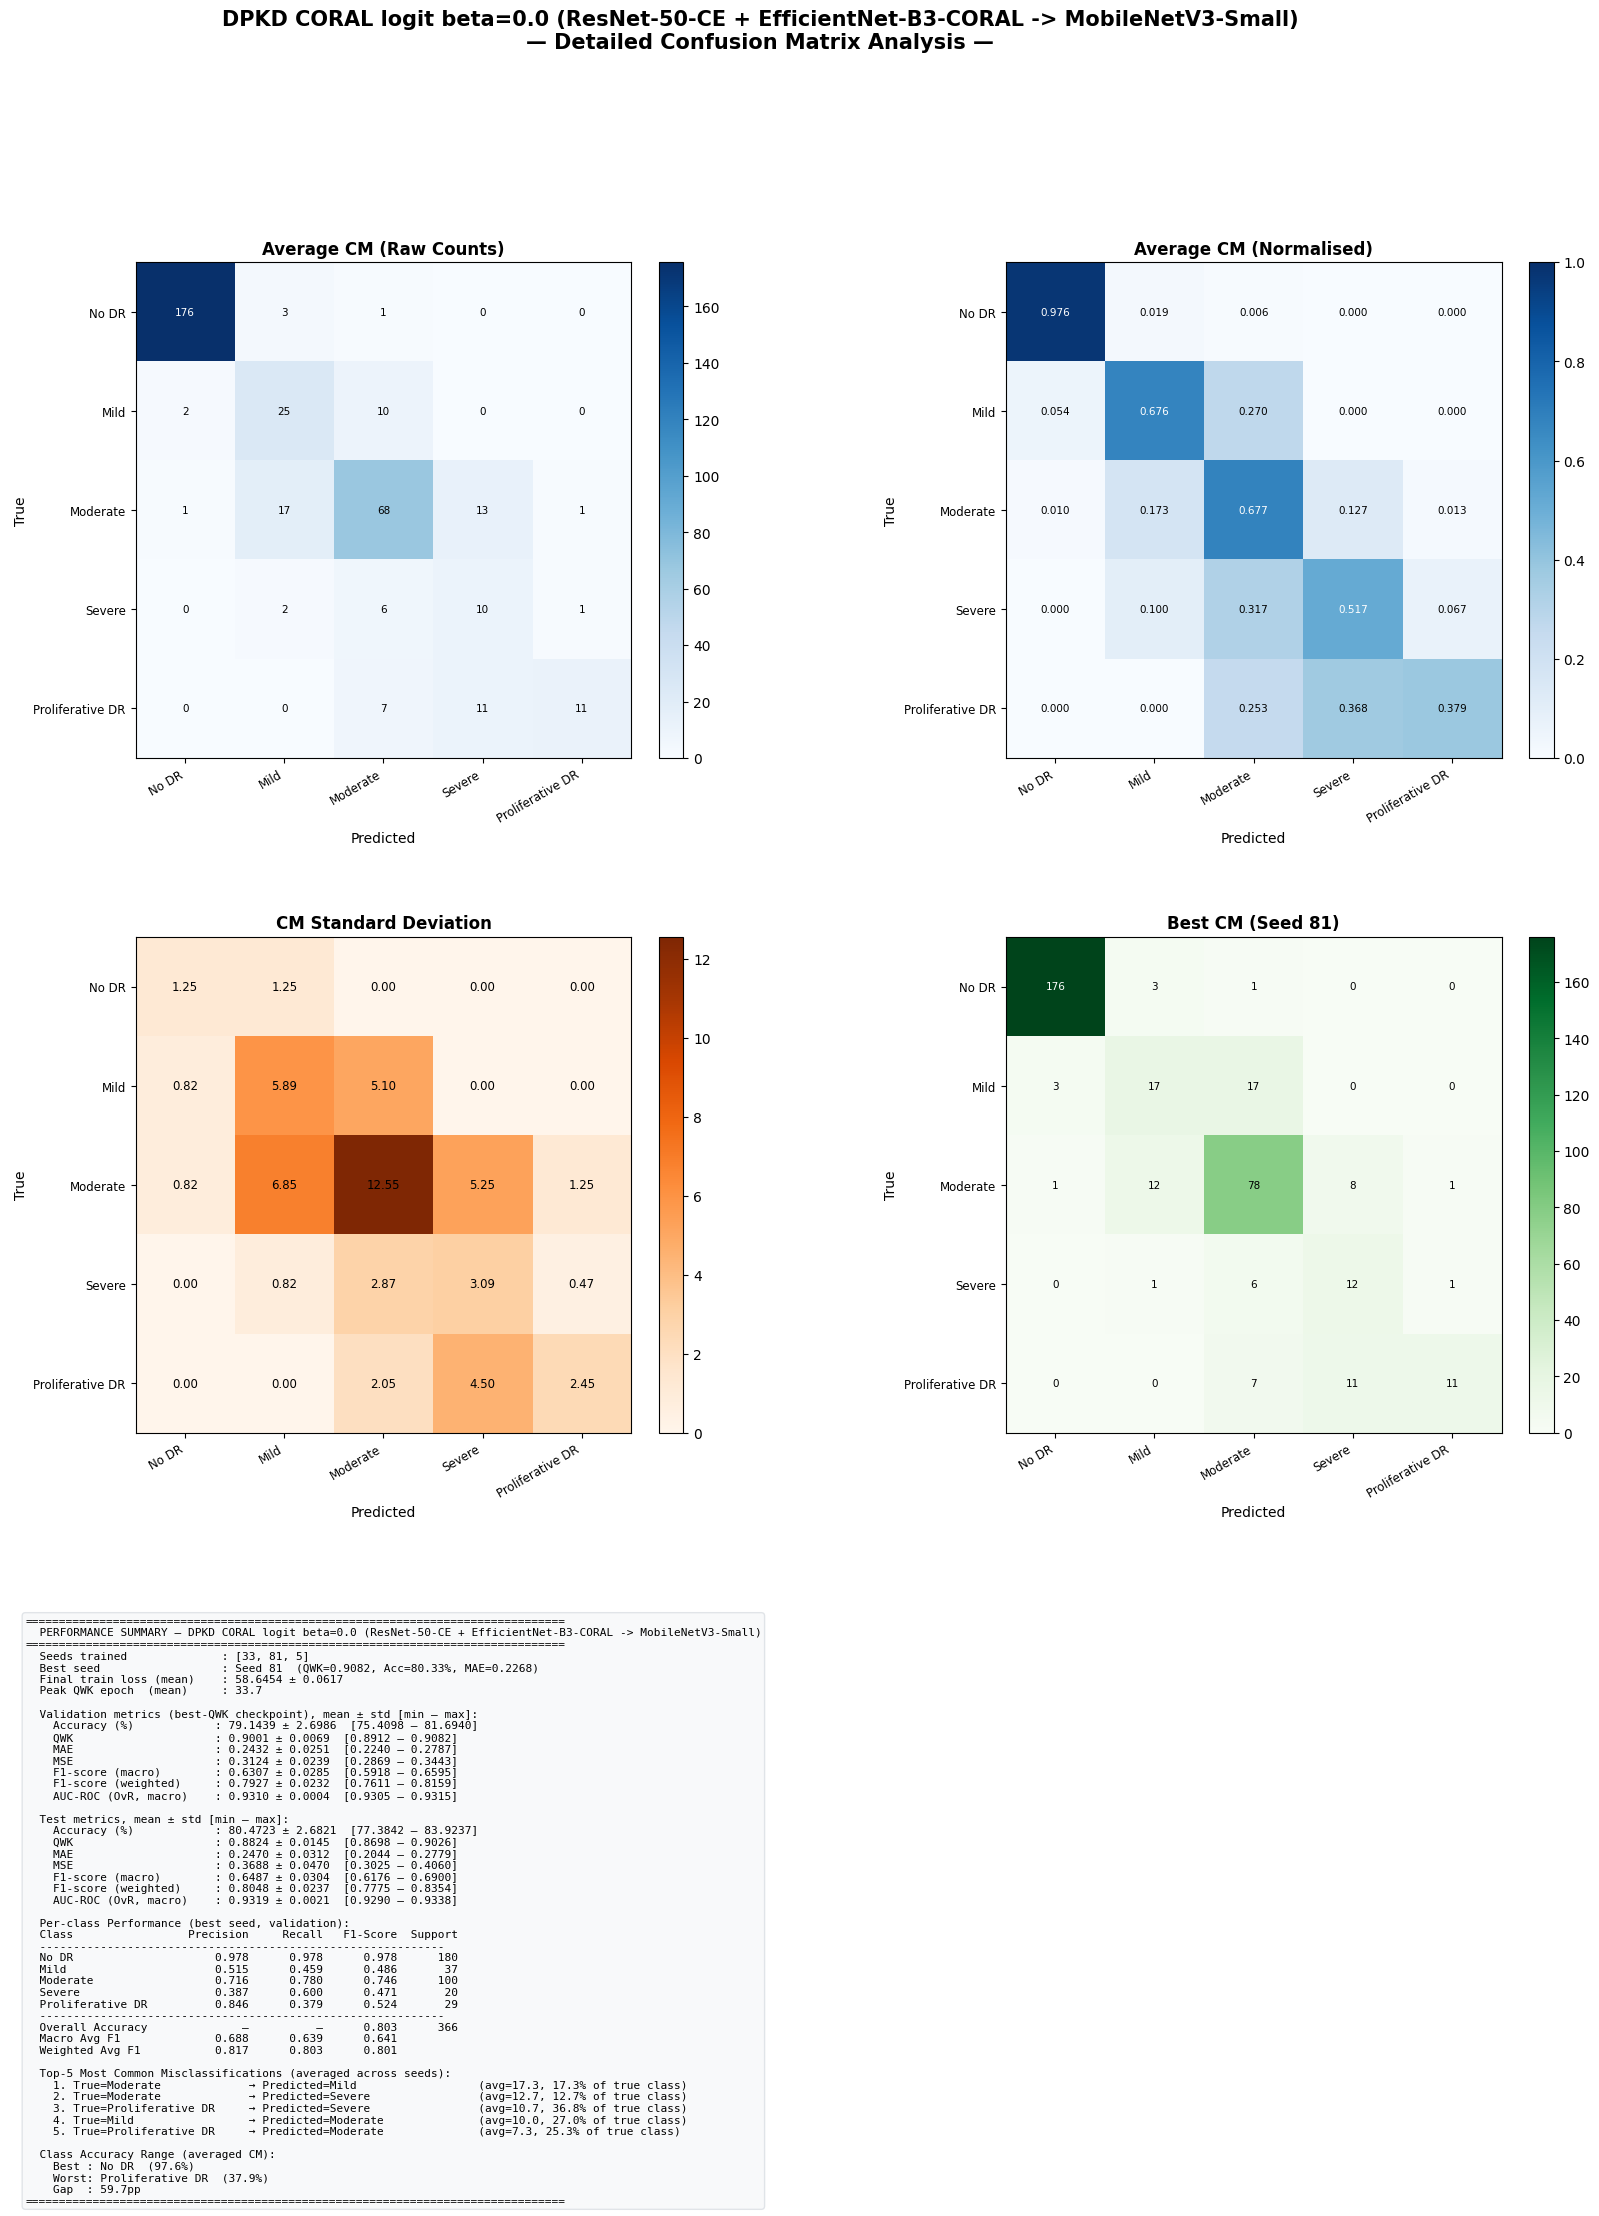

  PERFORMANCE SUMMARY — DPKD CORAL logit beta=0.0 (ResNet-50-CE + EfficientNet-B3-CORAL -> MobileNetV3-Small)
  Seeds trained              : [33, 81, 5]
  Best seed                  : Seed 81  (QWK=0.9082, Acc=80.33%, MAE=0.2268)
  Final train loss (mean)    : 58.6454 ± 0.0617
  Peak QWK epoch  (mean)     : 33.7

  Validation metrics (best-QWK checkpoint), mean ± std [min – max]:
    Accuracy (%)            : 79.1439 ± 2.6986  [75.4098 – 81.6940]
    QWK                     : 0.9001 ± 0.0069  [0.8912 – 0.9082]
    MAE                     : 0.2432 ± 0.0251  [0.2240 – 0.2787]
    MSE                     : 0.3124 ± 0.0239  [0.2869 – 0.3443]
    F1-score (macro)        : 0.6307 ± 0.0285  [0.5918 – 0.6595]
    F1-score (weighted)     : 0.7927 ± 0.0232  [0.7611 – 0.8159]
    AUC-ROC (OvR, macro)    : 0.9310 ± 0.0004  [0.9305 – 0.9315]

  Test metrics, mean ± std [min – max]:
    Accuracy (%)            : 80.4723 ± 2.6821  [77.3842 – 83.9237]
    QWK                     : 0.8824 ± 0.0145  [0.

In [25]:
analyse_results(
    results_dpkd,
    f"DPKD {ORDINAL_MODE.upper()} {KD_KIND} beta={BETA_FEAT} "
    f"(ResNet-50-CE + EfficientNet-B3-{ORDINAL_MODE.upper()} -> MobileNetV3-Small)",
    loss_label=f"DP-KD Loss ({KD_KIND}, {ORDINAL_MODE.upper()})",
    test_results_list=test_results_dpkd,
)

In [26]:
# Save a compact per-block summary (use it to build the 6-block comparison table)
summary = {
    'block': RUN_LABEL,
    'seeds': SEEDS,
    'val':  {k: [r['val_final'][k] for r in results_dpkd] for k, _, _ in METRIC_KEYS},
    'test': {k: [t[k] for t in test_results_dpkd]         for k, _, _ in METRIC_KEYS},
    'final_gate_nominal_weight': [r['history']['fusion_weight'][-1] for r in results_dpkd],
}
out_json = f'{CKPT_DIR}/summary_dpkd_{"feat" if USE_FEAT else "logit"}_{ORDINAL_MODE}.json'
with open(out_json, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Saved: {out_json}")

Saved: /kaggle/working//summary_dpkd_logit_coral.json
